In [24]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

In [26]:
#Load Data
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [28]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [29]:
df.drop("customerID", axis=1, inplace=True)

In [30]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [33]:
df.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [34]:
df.dropna(inplace=True)

In [35]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [36]:
# Encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [37]:
# Scale numerical columns
scaler = StandardScaler()
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[num_cols] = scaler.fit_transform(df[num_cols])

In [38]:
#Split
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [40]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [41]:
#Handle class Imbalance with smote
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)
print(f"After SMOTE:  {dict(zip(*np.unique(y_train, return_counts=True)))}")

After SMOTE:  {np.int64(0): np.int64(4130), np.int64(1): np.int64(4130)}


In [42]:
# Train Multiple Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(eval_metric="logloss", random_state=42),
    "LightGBM":            LGBMClassifier(random_state=42, verbose=-1),
}


In [43]:
results = {} 
for name, m in models.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    results[name] = {
        "Accuracy":  accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall":    recall_score(y_test, preds),
        "F1":        f1_score(y_test, preds),
        "ROC-AUC":   roc_auc_score(y_test, proba),
    }


In [44]:
# Print comparison table
print("\n── Model Comparison ──")
results_df = pd.DataFrame(results).T
print(results_df.round(4))



── Model Comparison ──
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.7214     0.4844  0.7487  0.5882   0.8187
Decision Tree          0.7129     0.4691  0.6096  0.5302   0.6799
Random Forest          0.7576     0.5372  0.6364  0.5826   0.8070
XGBoost                0.7406     0.5096  0.6364  0.5660   0.8000
LightGBM               0.7484     0.5207  0.6738  0.5874   0.8188


In [45]:
print("\n── Tuning LightGBM ──")
param_grid = {
    "n_estimators":    [100, 200],
    "max_depth":       [3, 5, 7],
    "learning_rate":   [0.05, 0.1, 0.2],
}
lgbm_tuned = GridSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_grid, cv=3, scoring="roc_auc", n_jobs=-1, verbose=1
)
lgbm_tuned.fit(X_train, y_train)
best_model = lgbm_tuned.best_estimator_
 
preds = best_model.predict(X_test)
proba = best_model.predict_proba(X_test)[:, 1]
 
print(f"Best params : {lgbm_tuned.best_params_}")
print(f"Accuracy    : {accuracy_score(y_test, preds):.4f}")
print(f"F1 Score    : {f1_score(y_test, preds):.4f}")
print(f"ROC-AUC     : {roc_auc_score(y_test, proba):.4f}")


── Tuning LightGBM ──
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best params : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Accuracy    : 0.7498
F1 Score    : 0.5810
ROC-AUC     : 0.8115


In [46]:
#feature Importance
importance_df = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False).head(10)

✅ Feature importance plot saved!


/tmp/ipykernel_20726/1557109745.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")


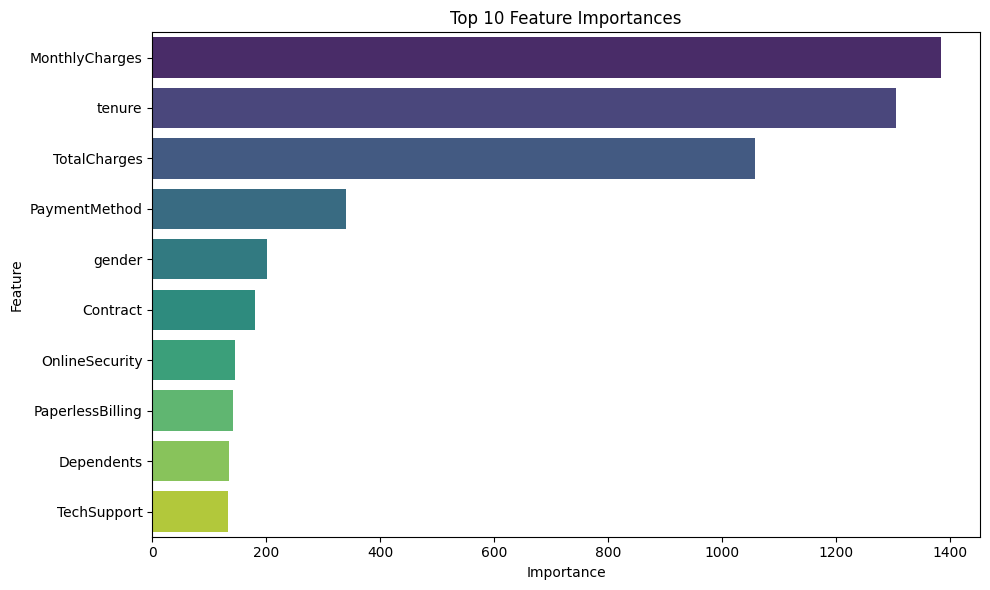

In [47]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.savefig("feature_importance.png")
print("✅ Feature importance plot saved!")

In [49]:
pickle.dump(best_model,    open("model.pkl",    "wb"))
pickle.dump(label_encoders, open("encoders.pkl", "wb"))
pickle.dump(scaler,         open("scaler.pkl",   "wb"))
pickle.dump(list(X.columns), open("features.pkl", "wb"))
print("\n🎉 Done!")


🎉 Done!
